# 1. Project Setup

## Objective

Build a machine learning model that predicts **bank customer churn**.

- Dataset: bank_churn_modelling.csv
- Task: Binary Classification
- Target Variable: churn

Meaning:

- 0 → Customer stayed
- 1 → Customer churned

The trained model will later be deployed through a **FastAPI API**.

In [1]:
# ======================================
# 2. Import Libraries
# ======================================

import pandas as pd
import numpy as np

In [2]:
# ======================================
# Load Dataset
# ======================================

url = "https://raw.githubusercontent.com/SagarChhabriya/data-science/main/datasets/04-Binary-Classification/bank_churn_modelling.csv"

df = pd.read_csv(url)

df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,Num Of Products,Has Credit Card,Is Active Member,Estimated Salary,Churn
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# ======================================
# Standardize Column Names
# ======================================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.columns

Index(['customerid', 'surname', 'creditscore', 'geography', 'gender', 'age',
       'tenure', 'balance', 'num_of_products', 'has_credit_card',
       'is_active_member', 'estimated_salary', 'churn'],
      dtype='object')

# 4. Exploratory Data Analysis

Initial inspection of the dataset helps us understand:

- data types
- missing values
- feature distributions
- target imbalance

In [4]:
# ======================================
# Dataset Structure
# ======================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        10000 non-null  int64  
 1   surname           10000 non-null  object 
 2   creditscore       10000 non-null  int64  
 3   geography         10000 non-null  object 
 4   gender            10000 non-null  object 
 5   age               10000 non-null  int64  
 6   tenure            10000 non-null  int64  
 7   balance           10000 non-null  float64
 8   num_of_products   10000 non-null  int64  
 9   has_credit_card   10000 non-null  int64  
 10  is_active_member  10000 non-null  int64  
 11  estimated_salary  10000 non-null  float64
 12  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [5]:
# ======================================
#  Summary Statistics
# ======================================

df.describe()

,customerid,creditscore,age,tenure,balance,num_of_products,has_credit_card,is_active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [6]:
# ======================================
# Target Distribution
# ======================================

df["churn"].value_counts()

,count
churn,
0,7963
1,2037


In [7]:
# ======================================
#  Remove Identifier Columns
# ======================================

df = df.drop(["customerid", "surname"], axis=1)

df.head()

,creditscore,geography,gender,age,tenure,balance,num_of_products,has_credit_card,is_active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Feature Selection

Prepare the dataset for machine learning modeling by selecting the relevant input variables.

- Features (X) represent customer attributes used to predict churn.

- Target (y) is the outcome the model learns to predict.

In this dataset:

Target variable

churn

1 → customer churned

0 → customer stayed

Feature variables

- creditscore

- geography

- gender

- age

- tenure

- balance

- num_of_products

- has_credit_card

- is_active_member

- estimated_salary

Identifier columns such as customerid and surname were removed earlier because they do not provide predictive information.

## Separate Features and Target

Split the dataset into:

- X (features) → input variables used for prediction

- y (target) → the variable the model will learn to predict

This separation is required before training any machine learning model.

Example:

X → customer characteristics

y → whether the customer churned

In [8]:
# ======================================
# Separate Features and Target
# ======================================

X = df.drop("churn", axis=1)
y = df["churn"]

X.head()

,creditscore,geography,gender,age,tenure,balance,num_of_products,has_credit_card,is_active_member,estimated_salary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


## Handle Categorical Features

Machine learning models cannot directly process text variables.

The dataset contains two categorical columns:

- geography

- gender

These must be converted into numerical representations using one-hot encoding.

In [ ]:
# ======================================
# One-Hot Encode Categorical Variables
# ======================================

X = pd.get_dummies(X, columns=["geography", "gender"], drop_first=True)

X.head()

## Train Test Split

Split the dataset into training and testing sets.

Training data is used to train the model, while the test set evaluates performance on unseen data.

14. Train-Test Split

To properly evaluate the model, we divide the data into:

Training set → used to train the model

Test set → used to evaluate model performance



In [10]:
# ======================================
# Train-Test Split
# ======================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (8000, 11)
Test set size: (2000, 11)


In [11]:
# ======================================
# Select Numerical Columns
# ======================================

num_cols = [
    "creditscore",
    "age",
    "tenure",
    "balance",
    "num_of_products",
    "estimated_salary"
]

## Feature Scaling

Some machine learning algorithms perform better when numerical features are standardized.

We apply StandardScaler to numerical variables so that:

- mean = 0
- standard deviation = 1

This improves convergence for gradient-based models such as Logistic Regression.

In [12]:
# ======================================
# Apply StandardScaler
# ======================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# Transform test data
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [13]:
# ======================================
# Inspect Scaled Features
# ======================================

X_train[num_cols].describe()

,creditscore,age,tenure,balance,num_of_products,estimated_salary
count,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03
mean,5.435652e-16,-1.896261e-16,6.661338e-17,-3.099743e-16,1.065814e-16,1.776357e-17
std,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00
min,-3.130418e+00,-1.986800e+00,-1.736467e+00,-1.218471e+00,-9.166877e-01,-1.744600e+00
25%,-6.916511e-01,-6.557859e-01,-6.953935e-01,-1.218471e+00,-9.166877e-01,-8.531146e-01
50%,1.403458e-02,-1.804237e-01,-1.344719e-03,3.257497e-01,-9.166877e-01,9.811339e-04
75%,6.989648e-01,4.850833e-01,6.927040e-01,8.247131e-01,8.084362e-01,8.548079e-01
max,2.058448e+00,5.048560e+00,1.733777e+00,2.798656e+00,4.258684e+00,1.730660e+00


# 9. Model Training

We train multiple classification models to compare performance:

- Logistic Regression
- Random Forest
- XGBoost

This allows us to select the most effective model for churn prediction.

In [14]:
# ======================================
# Import Machine Learning Models
# ======================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

## Train Logistic Regression

Logistic Regression is a linear classification algorithm commonly used as a baseline model.

It estimates the probability that a customer will churn using a logistic function. Because this model relies on gradient optimization, it benefits from feature scaling, which we already applied using StandardScaler.

In [15]:
# ======================================
# Train Logistic Regression
# ======================================

log_model = LogisticRegression(max_iter=5000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

log_prob = log_model.predict_proba(X_test)[:,1]

In [16]:
# ======================================
# Train Random Forest
# ======================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:,1]

### Train XGBoost

XGBoost (Extreme Gradient Boosting) is a powerful boosting algorithm widely used in machine learning competitions and production systems.

Instead of building trees independently (like Random Forest), XGBoost builds trees sequentially, where each new tree corrects errors made by previous trees.

Advantages:

- high predictive performance

- andles complex patterns

- efficient and scalable

In [17]:
# ======================================
# Train XGBoost Model
# ======================================

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:,1]

23. Model Evaluation

To assess model performance we evaluate:

Accuracy → overall prediction correctness

Confusion Matrix → breakdown of prediction outcomes

ROC-AUC → ability to distinguish churn vs non-churn

These metrics help determine which model performs best.

In [18]:
# ======================================
# Import Evaluation Metrics
# ======================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

In [19]:
# ======================================
# Logistic Regression Evaluation
# ======================================

print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, log_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, log_pred))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, log_prob))

Logistic Regression Accuracy:
0.8115

Confusion Matrix:
[[1544   63]
 [ 314   79]]

ROC-AUC Score:
0.7789869701734301


In [20]:
# ======================================
# Random Forest Evaluation
# ======================================

print("Random Forest Accuracy:")
print(accuracy_score(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, rf_prob))

Random Forest Accuracy:
0.8705

Confusion Matrix:
[[1553   54]
 [ 205  188]]

ROC-AUC Score:
0.8627600938008173


In [21]:
# ======================================
# XGBoost Evaluation
# ======================================

print("XGBoost Accuracy:")
print(accuracy_score(y_test, xgb_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, xgb_prob))

XGBoost Accuracy:
0.8675

Confusion Matrix:
[[1539   68]
 [ 197  196]]

ROC-AUC Score:
0.8694824329309906


## Feature Importance Analysis

Feature importance helps identify which variables influence the model’s predictions the most.

Understanding important features provides:

- interpretability for stakeholders
 insight into customer behavior

- guidance for business decision-making

Tree-based models such as Random Forest and XGBoost naturally provide feature importance scores.In this project we examine XGBoost feature importance, since it was selected as the final model.

In [22]:
# ======================================
# Extract Feature Importance
# ======================================

import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(10)

,feature,importance
4,num_of_products,0.271280
6,is_active_member,0.216887
1,age,0.163930
8,geography_Germany,0.107471
10,gender_Male,0.054936
3,balance,0.053161
9,geography_Spain,0.036271
0,creditscore,0.026051
2,tenure,0.025395
5,has_credit_card,0.022525


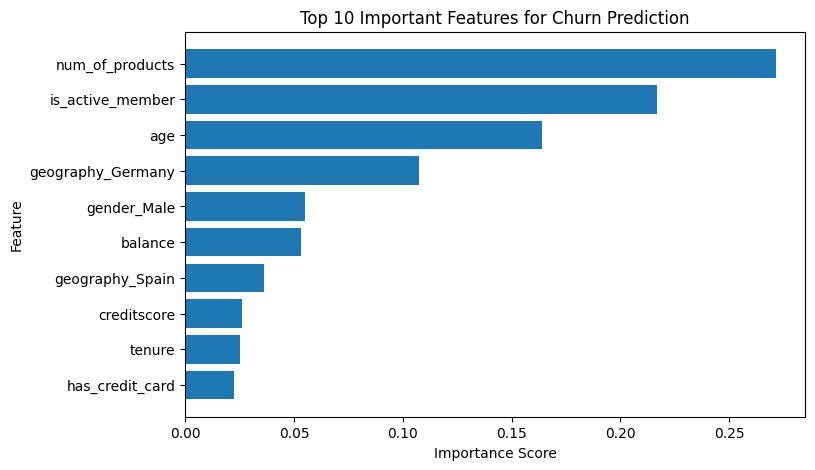

In [23]:
# ======================================
# Plot Feature Importance
# ======================================

import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 Important Features for Churn Prediction")
plt.gca().invert_yaxis()

plt.show()

# Model Export

The final trained model is saved as a serialized file so it can be used in a production API.

We save:

- churn_model.pkl
- scaler.pkl

In [24]:
# ======================================
# Save Model
# ======================================

import pickle

with open("churn_model.pkl", "wb") as file:
    pickle.dump(xgb_model, file)

In [25]:
# ======================================
# Save Scaler
# ======================================

with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

In [26]:
from google.colab import files

files.download("churn_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 13. Conclusion

In this notebook we:

- prepared and cleaned the dataset
- trained multiple classification models
- evaluated model performance
- selected the best model (XGBoost)
- exported the trained model for deployment

The model will now be served through a FastAPI backend for real-time predictions.